In [2]:
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt

Question 5:

In [3]:
#Question 5
v1 = np.array([1,2,3])

v2 = np.array([-1,-1,0])

distance = np.linalg.norm(v1-v2)
print("Distance between vectors: ", distance)

# calculate degrees
dot_matrix = np.dot(v1, v2)

cos_angle = dot_matrix / (np.linalg.norm(v1) * np.linalg.norm(v2))
degrees = np.degrees(cos_angle)

print("cos theta = ",cos_angle )
cos_angle_ = np.arccos(cos_angle)
print("theta = ", cos_angle_, "\ntheta degrees: ", degrees)

Distance between vectors:  4.69041575982343
cos theta =  -0.5669467095138409
theta =  2.1735908795471617 
theta degrees:  -32.48365366397256


In [36]:
#Question 6
B = np.array([[3,2,2], [2,3,-2]])
print("original matrix \n", B)
U, E, V_transp = np.linalg.svd(B)

print("U \n", U)
print("E \n", E)
print("V_transp \n", V_transp)

#Make a 2x3 diagonal matrix for E since E only returns 1d array of singular values
full_E_matrix = np.zeros((2,3))
np.fill_diagonal(full_E_matrix, E)

#Get the K column of U, the k x k columns and rows of E, and the K row of VT
#since these vectors hold the most significant information

U_1_approx = U[:, :1]
E_1_approx = full_E_matrix[:1, :1]
V_transp_approx = V_transp[:1, :]


B_k = U_1_approx @ E_1_approx @ V_transp_approx
print(f"Rank 1 approximation: \n {np.round(B_k, 2)}")

original matrix 
 [[ 3  2  2]
 [ 2  3 -2]]
U 
 [[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]
E 
 [5. 3.]
V_transp 
 [[-7.07106781e-01 -7.07106781e-01 -6.47932334e-17]
 [-2.35702260e-01  2.35702260e-01 -9.42809042e-01]
 [-6.66666667e-01  6.66666667e-01  3.33333333e-01]]
Rank 1 approximation: 
 [[2.5 2.5 0. ]
 [2.5 2.5 0. ]]


Question 7

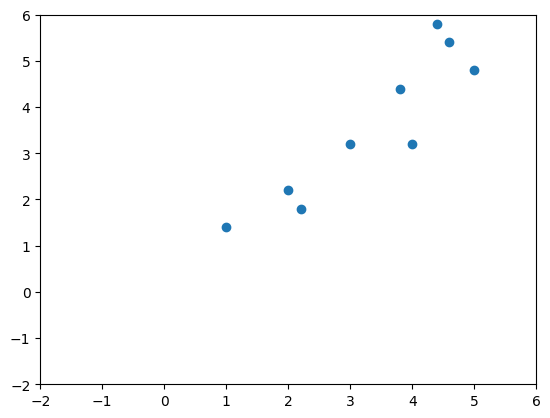

original unnormalized data: [5.  1.  4.4 3.8 6.2 4.6 4.  2.  3.  2.2]
original unnormalized data: [4.8 1.4 5.8 4.4 6.  5.4 3.2 2.2 3.2 1.8]
x mean 3.62
y mean 3.82
normalized x vals: [ 1.38 -2.62  0.78  0.18  2.58  0.98  0.38 -1.62 -0.62 -1.42]
normalized y vals: [ 0.98 -2.42  1.98  0.58  2.18  1.58 -0.62 -1.62 -0.62 -2.02]


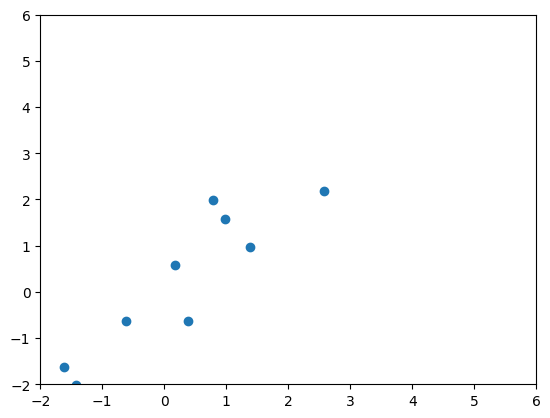

The data points are now centered around the origin as seen in the scatter plot
covariance matrix: 
 [[2.46622222 2.46177778]
 [2.46177778 2.86622222]]
eigenvalues and eigenvectors

eigenvalues:  [0.1963336  5.13611085]
eigenvectors: 
 [[-0.73517866 -0.6778734 ]
 [ 0.6778734  -0.73517866]]
eigen vectors shape: (2, 2)
As seen above, the largest eigenvalue is approxiately 5.14.The eigen vector corresponding to that eigenvalue is [ -0.6778734   -0.73517866]]. This vector is the first Principal component
Principal Component k=1: 

principal component [-0.6778734  -0.73517866]
1 dimensional Principal component matrix
 [-1.65594037  3.55516065 -1.98439499 -0.54842083 -3.35160284 -1.82589821
  0.19821887  2.28914433  0.87609227  2.44764111] shape: 
 (10,)
If the Formula for PC1 = Z * V where V is the eigenvector, Z is the normailized original dataset, and PC1 is the 1 dimensional principal componentmatrix, then to get Z, we can use formula Z =  PC1 * VT + mean
original matrix:
 [[ 1.12251793  

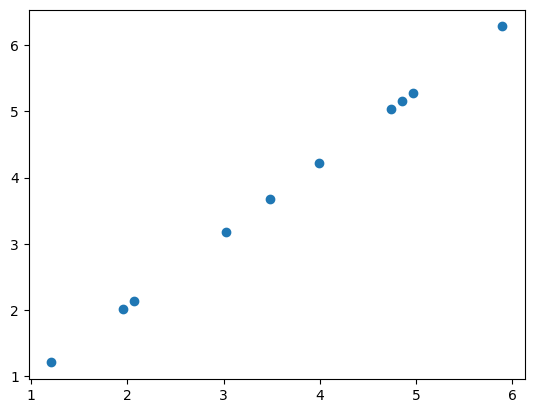

We can see that, while very close, there was some data loss in the points after performing principal component analysis of 1D and reconstructing


In [11]:

#Task A
X_vals = np.array([5.0, 1.0, 4.4, 3.8, 6.2, 4.6, 4.0, 2.0, 3.0, 2.2])
y_vals = np.array([4.8, 1.4, 5.8, 4.4, 6.0, 5.4, 3.2, 2.2, 3.2, 1.8])

#creates a scatter plot of x and y vals
plt.scatter(X_vals, y_vals)
plt.xlim(-2,6)
plt.ylim(-2,6)
plt.show()

#Task B - Normalize the data and plot
def normalize_data(array):
    print(f"original unnormalized data: {array}")
    mean_ = np.mean(array)
    normalized_data = []
    for data_point in array:
        normalized_data.append(data_point - mean_)
    return mean_, np.array(normalized_data)

x_mean, normalized_x_vals = normalize_data(X_vals)
y_mean, normalized_y_vals = normalize_data(y_vals)

print(f"x mean {x_mean:.2f}")
print(f"y mean {y_mean:.2f}")
print(f"normalized x vals: {normalized_x_vals}")
print(f"normalized y vals: {normalized_y_vals}")

plt.scatter(normalized_x_vals, normalized_y_vals)
plt.xlim(-2,6)
plt.ylim(-2,6)
plt.show()
print("The data points are now centered around the origin as seen in the scatter plot\n")



In [12]:
#Task C
covariance_matrix = np.cov(normalized_x_vals, normalized_y_vals)
print("covariance matrix: \n", covariance_matrix)

#Task D
print("eigenvalues and eigenvectors\n")
eigenvalues, eigenvectors = LA.eig(covariance_matrix)
print("eigenvalues: \n", eigenvalues)
print("eigenvectors: \n", eigenvectors)
print("eigen vectors shape:", eigenvectors.shape)



covariance matrix: 
 [[2.46622222 2.46177778]
 [2.46177778 2.86622222]]
eigenvalues and eigenvectors

eigenvalues: 
 [0.1963336  5.13611085]
eigenvectors: 
 [[-0.73517866 -0.6778734 ]
 [ 0.6778734  -0.73517866]]
eigen vectors shape: (2, 2)


As seen above, the largest eigenvalue is approxiately 5.14. \
The eigen vector corresponding to that eigenvalue is [ -0.6778734   -0.73517866]].  \
This vector is the first Principal component


In [ ]:
#Task E
print("Principal Component k=1: \n")

#creating matrix of standardized x and y vals
x_col = normalized_x_vals.reshape(-1,1)
y_col = normalized_y_vals.reshape(-1,1)
Z = np.hstack((x_col, y_col))

principal_component = eigenvectors[:, 1]


principal_component_1D = Z @ principal_component
print("principal component", principal_component)
print("1 dimensional Principal component matrix\n", principal_component_1D, "shape: \n", principal_component_1D.shape)



If the Formula for PC1 = Z * V where V is the eigenvector, Z is " \
the normailized original dataset, and PC1 is the 1 dimensional principal component \
matrix, then to get Z, we can use formula Z =  PC1 * VT + mean to approximate original data set


original matrix:
 [[ 1.12251793  1.21741202]
 [-2.40994883 -2.61367823]
 [ 1.34516858  1.45888484]
 [ 0.37175989  0.40318729]
 [ 2.27196241  2.46402687]
 [ 1.23772782  1.34236139]
 [-0.1343673  -0.14572629]
 [-1.55175005 -1.68293005]
 [-0.59387965 -0.64408434]
 [-1.6591908  -1.7994535 ]]
reconstruced matrix: 
 [[4.74251793 5.03741202]
 [1.21005117 1.20632177]
 [4.96516858 5.27888484]
 [3.99175989 4.22318729]
 [5.89196241 6.28402687]
 [4.85772782 5.16236139]
 [3.4856327  3.67427371]
 [2.06824995 2.13706995]
 [3.02612035 3.17591566]
 [1.9608092  2.0205465 ]]
reconstruced matrix shape: 
 (10, 2)


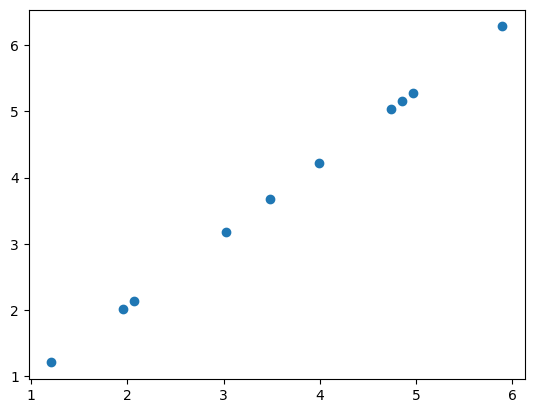

In [14]:
#Task F
#transpose to 1x2 matrix
principal_component_transposed = principal_component.reshape(1,2)

#reconstruct original matrix
principal_component_1D = principal_component_1D.reshape(10,1)
original_matrix_approx = principal_component_1D @ principal_component_transposed
original_matrix_approx = original_matrix_approx.reshape(-1,2)
print("original matrix:\n", original_matrix_approx)

#After adding the mean
original_matrix_xvals = original_matrix_approx[:, 0] + x_mean
original_matrix_yvals = original_matrix_approx[:, 1] + y_mean

original_matrix_ = np.column_stack((original_matrix_xvals,original_matrix_yvals))
original_matrix_ = original_matrix_.reshape(10,2)
print("reconstruced matrix: \n",original_matrix_ )
print("reconstruced matrix shape: \n",original_matrix_.shape)

#Task G
plt.scatter(original_matrix_xvals, original_matrix_yvals)
plt.show()



We can see that the points on the graph lie on a 1 dimensional line that shows the maximum amount of information we can get from the original dataset with 1 principal component.

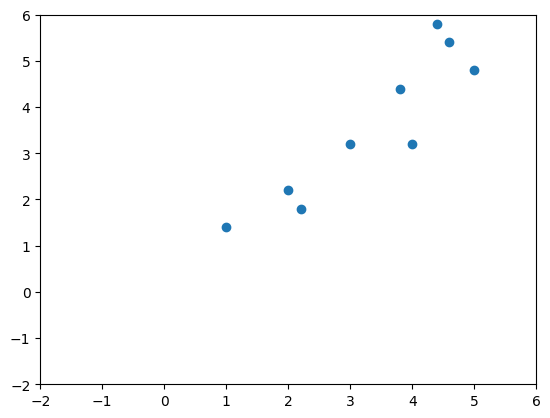

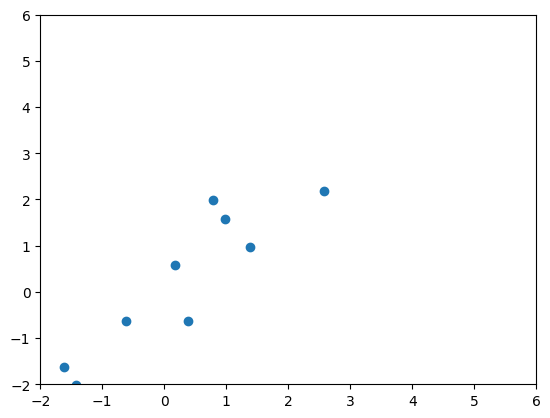

U 
 [[-0.24356016  0.26347265 -0.39047584 -0.11221448 -0.50685797 -0.32757587
   0.09436587  0.36336861  0.139067    0.42626858]
 [ 0.52290258 -0.21493822 -0.48486399 -0.16654284  0.33633503 -0.20613584
   0.4674178  -0.09966063 -0.03814172  0.17906752]
 [-0.29187014 -0.57831779  0.52915908 -0.15284629  0.01137288 -0.26566296
   0.3395712   0.08303874  0.03178026  0.2882167 ]
 [-0.08066321 -0.19622138 -0.15001574  0.95111825  0.01012104 -0.08329367
   0.11054807  0.02275085  0.00870712  0.08947292]
 [-0.49296275  0.3152044  -0.08911177 -0.02243033  0.77149128 -0.09819865
  -0.01938774  0.14729031  0.05637037  0.13820343]
 [-0.26855801 -0.26372412 -0.2865383  -0.0916674  -0.04099788  0.82837125
   0.18927277  0.07786875  0.02980162  0.19277829]
 [ 0.02915456  0.52633457  0.30312782  0.10075907 -0.09097716  0.15365497
   0.75104398 -0.00574156 -0.00219739 -0.15521441]
 [ 0.3366935  -0.06983786  0.14035745  0.04185709  0.12818407  0.1065281
  -0.05350715  0.90019323 -0.03819765 -0.1336361

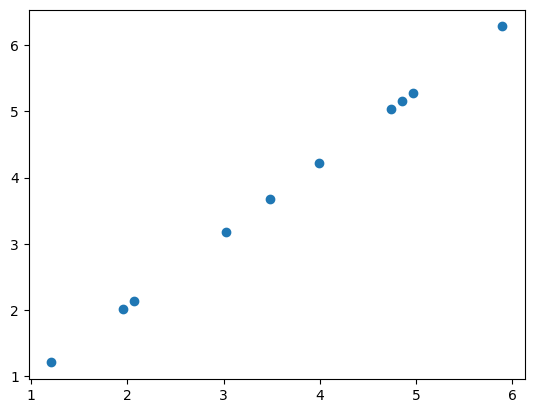

In [31]:
#Question 8
#plot figures
plt.scatter(X_vals, y_vals)
plt.xlim(-2,6)
plt.ylim(-2,6)
plt.show()

plt.scatter(normalized_x_vals, normalized_y_vals)
plt.xlim(-2,6)
plt.ylim(-2,6)
plt.show()

#calculate SVD of above normalized dataset
Z_ = Z
U, E, V_transp = np.linalg.svd(Z_)

print("U \n", U)
print("E \n", E)
print("V_transp \n", V_transp)

# transpose V since V_transp returns the transposed matrix already
V_ = V_transp.T

#Getting the 1st column which relates to th most important right singular values
print(V_.shape)
V_1 = V_[:, 0:1]
print("Most important singular value: ", V_1)

#project that data onto original normalized data
X_reduced = Z_ @ V_1
print("1 Dimension Reduced Principal component matrix: \n", X_reduced)

x_reconstructed = X_reduced @ V_1.T

x_col_SVD = x_reconstructed[:, 0] + x_mean
y_col_SVD = x_reconstructed[:, 1] + y_mean
x_reconstructed = np.column_stack((x_col_SVD, y_col_SVD))
print(x_reconstructed)

plt.scatter(x_col_SVD, y_col_SVD)
plt.show()

We got the same values using the SVD method because V from the SVD formula gives you the eigenvectors which can be used to perform PCA. We can extract the needed values from matrix V and dot product with a dataset to get the reduced principal component method the same as using the tradiditional method.